# Lab 2 Task4 GNN Part here

In [ ]:
!pip install torch_geometric
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
import torch


from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import torch.optim as optim
import torch.nn as nn
import torch

from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from scipy.io.arff import loadarff
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00


In [ ]:
!pip install gdown

import gdown
import pandas as pd


train_url = "https://drive.google.com/uc?id=1yVsTc5V62ASrDJp6dsMSHyYt-dFhhc-i"
test_url  = "https://drive.google.com/uc?id=1bH_IOB3_XxuV2yR--HcXAk85pFtpK3Y5"

# gdown will handle extraction of the ID automatically
gdown.download(train_url, "data_train.json", quiet=False)
gdown.download(test_url, "data_test.json", quiet=False)

# Load JSON files
train_df = pd.read_json("data_train.json")
test_df = pd.read_json("data_test.json")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Downloading...
From: https://drive.google.com/uc?id=1yVsTc5V62ASrDJp6dsMSHyYt-dFhhc-i
To: /content/data_train.json
100%|██████████| 39.5M/39.5M [00:00<00:00, 61.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bH_IOB3_XxuV2yR--HcXAk85pFtpK3Y5
To: /content/data_test.json
100%|██████████| 18.1M/18.1M [00:00<00:00, 140MB/s]


Train shape: (16325, 2)
Test shape: (6505, 2)


In [ ]:
train_df

,api_call_sequence,is_malware
0,"[LdrGetDllHandle, LdrGetProcedureAddress, LdrL...",1
1,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1
2,"[FindResourceExW, LoadResource, FindResourceEx...",1
3,"[FindResourceExW, LoadResource, FindResourceEx...",1
4,"[LdrGetProcedureAddress, SetErrorMode, LdrLoad...",1
...,...,...
16320,"[LdrGetProcedureAddress, LdrLoadDll, LdrGetPro...",1
16321,"[NtClose, LdrGetProcedureAddress, CryptCreateH...",1
16322,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1
16323,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1


In [ ]:


# 1. Remove empty api calls entries from dataset
train_df = train_df[train_df['api_call_sequence'].apply(len) > 0]
test_df = test_df[test_df['api_call_sequence'].apply(len) > 0]

train_df

,api_call_sequence,is_malware
0,"[LdrGetDllHandle, LdrGetProcedureAddress, LdrL...",1
1,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1
2,"[FindResourceExW, LoadResource, FindResourceEx...",1
3,"[FindResourceExW, LoadResource, FindResourceEx...",1
4,"[LdrGetProcedureAddress, SetErrorMode, LdrLoad...",1
...,...,...
16320,"[LdrGetProcedureAddress, LdrLoadDll, LdrGetPro...",1
16321,"[NtClose, LdrGetProcedureAddress, CryptCreateH...",1
16322,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1
16323,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1


In [ ]:
#dropping duplicates, since the sequence have cut, there might be some sequence that deferred just for the last api calls
train_df['api_call_sequence'] = train_df['api_call_sequence'].apply(tuple)
test_df['api_call_sequence'] = test_df['api_call_sequence'].apply(tuple)
# Now you can drop duplicates
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [ ]:
train_df['api_call_sequence'] = train_df['api_call_sequence'].apply(list)
test_df['api_call_sequence'] = test_df['api_call_sequence'].apply(list)
train_df


,api_call_sequence,is_malware
0,"[LdrGetDllHandle, LdrGetProcedureAddress, LdrL...",1
1,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1
2,"[FindResourceExW, LoadResource, FindResourceEx...",1
3,"[FindResourceExW, LoadResource, FindResourceEx...",1
4,"[LdrGetProcedureAddress, SetErrorMode, LdrLoad...",1
...,...,...
16320,"[LdrGetProcedureAddress, LdrLoadDll, LdrGetPro...",1
16321,"[NtClose, LdrGetProcedureAddress, CryptCreateH...",1
16322,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1
16323,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1


In [ ]:
# Function to encode a sequence (tokens not in the mapping get mapped to "<UNK>")
def encode_seq(seq, mapping):
    return [mapping.get(token, mapping["<UNK>"]) for token in seq]

from collections import Counter

# Extract all API calls from the training set
all_calls = [api for seq in train_df['api_call_sequence'] for api in seq]
call_counter = Counter(all_calls)
print("Top 10 most common API calls:")
print(call_counter.most_common(10))

# Build a vocabulary list and add a special <UNK> token for out-of-vocabulary API calls.
vocab = list(call_counter.keys())
vocab.append("<UNK>")
print("Vocabulary size:", len(vocab))

# Create a mapping: API call -> integer ID
api_to_int = {api: idx for idx, api in enumerate(vocab, start=1)}
int_to_api = {idx: api for api, idx in api_to_int.items()}



# Encode sequences in training and test sets
train_df['seq_encoded'] = train_df['api_call_sequence'].apply(lambda x: encode_seq(x, api_to_int))
test_df['seq_encoded']  = test_df['api_call_sequence'].apply(lambda x: encode_seq(x, api_to_int))


Top 10 most common API calls:
[('LdrGetProcedureAddress', 170696), ('LdrLoadDll', 91296), ('RegOpenKeyExW', 86046), ('LdrGetDllHandle', 71498), ('NtClose', 67682), ('RegQueryValueExW', 64074), ('RegCloseKey', 61993), ('NtAllocateVirtualMemory', 54789), ('LoadResource', 36327), ('FindResourceExW', 32102)]
Vocabulary size: 259


In [ ]:
api_to_int

{'LdrGetDllHandle': 1,
 'LdrGetProcedureAddress': 2,
 'LdrLoadDll': 3,
 'GetTimeZoneInformation': 4,
 'LoadStringW': 5,
 'RegOpenKeyExW': 6,
 'RegQueryValueExW': 7,
 'RegCloseKey': 8,
 'SetErrorMode': 9,
 'GetSystemMetrics': 10,
 'FindResourceExW': 11,
 'OleInitialize': 12,
 'LoadResource': 13,
 'NtClose': 14,
 'NtAllocateVirtualMemory': 15,
 'LookupAccountSidW': 16,
 'DrawTextExW': 17,
 'GetSystemTimeAsFileTime': 18,
 'GetSystemInfo': 19,
 'NtCreateMutant': 20,
 'NtOpenKey': 21,
 'NtOpenKeyEx': 22,
 'NtQuerySystemInformation': 23,
 'NtProtectVirtualMemory': 24,
 'GetSystemDirectoryW': 25,
 'NtQueryValueKey': 26,
 'NtEnumerateKey': 27,
 'NtEnumerateValueKey': 28,
 'GetSystemWindowsDirectoryW': 29,
 'CreateActCtxW': 30,
 'NtOpenDirectoryObject': 31,
 'NtFreeVirtualMemory': 32,
 'LoadStringA': 33,
 'FindResourceA': 34,
 'SizeofResource': 35,
 'NtCreateFile': 36,
 'NtCreateSection': 37,
 'NtMapViewOfSection': 38,
 'RegOpenKeyExA': 39,
 'RegQueryValueExA': 40,
 'NtOpenProcess': 41,
 'LdrUn

In [ ]:
from torch_geometric.data import Data, Dataset
import torch
import numpy as np

class GraphDataset(Dataset):
    """
    Safe PyG Dataset:
    - Reindexes nodes locally (0..N-1)
    - Ensures x is float (for GCN/SAGE/GAT)
    - Ensures y is a scalar tensor
    - Ensures edge_index matches local indexing
    """

    def __init__(self, adj_matrices, features, labels, transform=None):
        super().__init__(transform)
        self.graphs = []

        for i in range(len(adj_matrices)):

            # ---- 1. build edge_index from adjacency ----
            edge_rows, edge_cols = adj_matrices[i].nonzero()
            if len(edge_rows) == 0:
                # empty graph → must still have correct shape
                edge_index = torch.empty((2, 0), dtype=torch.long)
            else:
                edge_index = torch.tensor(
                    np.vstack([edge_rows, edge_cols]),
                    dtype=torch.long
                )

            # ---- 2. build node features ----
            # ALWAYS float for GCN/SAGE/GAT
            x = torch.tensor(features[i], dtype=torch.float32)

            # ---- 3. graph label as scalar ----
            y = torch.tensor(int(labels[i]), dtype=torch.long)

            # ---- 4. create Data object ----
            data = Data(x=x, edge_index=edge_index, y=y)
            self.graphs.append(data)

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        return self.graphs[idx]


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

#Plot the graph using the networkx library
def plot_graph(data):
    """Visualize a PyTorch Geometric graph with node and edge features."""
    G = to_networkx(data, to_undirected=True)

    # Get node positions for consistent layout
    pos = nx.spring_layout(G, seed=42)

    # Draw the graph structure
    plt.figure(figsize=(7, 7))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
            node_size=800, font_size=7)

    # Format node features
    node_labels = {i: f"{[round(f, 2) for f in data.x[i].tolist()]}" for i in range(data.x.shape[0])}

    # Display node features slightly above nodes
    offset = 0.1
    pos_shifted = {k: (v[0], v[1] + offset) for k, v in pos.items()}
    nx.draw_networkx_labels(G, pos_shifted, labels=node_labels, font_size=8, font_color="darkred")

    # Add edge features if available
    if hasattr(data, "edge_attr") and data.edge_attr is not None:
        edge_labels = {(u, v): f"{[round(e, 2) for e in data.edge_attr[idx].tolist()]}"
                       for idx, (u, v) in enumerate(data.edge_index.T.tolist())}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="darkblue")

    plt.title(f"Graph Example - Label: {data.y.item()}")
    plt.show()

In [ ]:
# now we need to create the ADJ_MATRIX AND THE FEATURE MATRIX
# We use Networkx to prepare the data to go from list  to graph  to adj matrix and feature matrix

import numpy as np

import torch
from scipy.sparse import lil_matrix
import networkx as nx
from scipy.sparse import lil_matrix



def create_adj_from_list(seq):
    """
    Build adjacency (scipy.sparse lil_matrix) for a single API-call sequence.
    Nodes are the unique API IDs in order of first appearance, reindexed to 0..N-1.
    Edges are undirected between consecutive calls (you can change to directed if desired).
    """
    unique_nodes = list(dict.fromkeys(seq))  # preserves first occurrence order
    N = max(1, len(unique_nodes))
    if N == 1:
        # single node graph
        return lil_matrix((1, 1))
    idx_map = {api_id: i for i, api_id in enumerate(unique_nodes)}
    edges = []
    for i in range(len(seq) - 1):
        u = idx_map[seq[i]]
        v = idx_map[seq[i + 1]]
        if u != v:
            edges.append((u, v))
    G = nx.Graph()
    G.add_nodes_from(range(N))
    if edges:
        G.add_edges_from(edges)
    # return sparse adjacency with shape (N, N)
    adj = nx.to_scipy_sparse_array(G, nodelist=range(N), format='lil')
    return adj




data_list = [1, 2, 3, 5, 2, 5]
print(create_adj_from_list(data_list))


# now we add the graph rappresentation in the dataset
train_df['adj_matrix'] = train_df['seq_encoded'].apply(lambda x: create_adj_from_list(x))
test_df['adj_matrix'] = test_df['seq_encoded'].apply(lambda x: create_adj_from_list(x))


train_df

<List of Lists sparse array of dtype 'int64'
	with 8 stored elements and shape (4, 4)>
  Coords	Values
  (0, 1)	1
  (1, 0)	1
  (1, 2)	1
  (1, 3)	1
  (2, 1)	1
  (2, 3)	1
  (3, 1)	1
  (3, 2)	1


,api_call_sequence,is_malware,seq_encoded,adj_matrix
0,"[LdrGetDllHandle, LdrGetProcedureAddress, LdrL...",1,"[1, 2, 3, 2, 1, 2, 4, 5, 6, 7, 8, 1, 2, 1, 2, ...",<List of Lists sparse array of dtype 'int64'\n...
1,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1,"[15, 3, 2, 18, 19, 20, 18, 21, 22, 23, 24, 25,...",<List of Lists sparse array of dtype 'int64'\n...
2,"[FindResourceExW, LoadResource, FindResourceEx...",1,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1...",<List of Lists sparse array of dtype 'int64'\n...
3,"[FindResourceExW, LoadResource, FindResourceEx...",1,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1...",<List of Lists sparse array of dtype 'int64'\n...
4,"[LdrGetProcedureAddress, SetErrorMode, LdrLoad...",1,"[2, 9, 3, 9, 10, 11, 13, 11, 13, 11, 13, 11, 1...",<List of Lists sparse array of dtype 'int64'\n...
...,...,...,...,...
16320,"[LdrGetProcedureAddress, LdrLoadDll, LdrGetPro...",1,"[2, 3, 2, 3, 2, 3, 2, 3, 2, 24, 18, 15, 32, 15...",<List of Lists sparse array of dtype 'int64'\n...
16321,"[NtClose, LdrGetProcedureAddress, CryptCreateH...",1,"[14, 2, 48, 2, 49, 2, 36, 50, 51, 52, 14, 6, 7...",<List of Lists sparse array of dtype 'int64'\n...
16322,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1,"[2, 1, 2, 10, 96, 3, 2, 11, 13, 11, 13, 1, 2, ...",<List of Lists sparse array of dtype 'int64'\n...
16323,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1,"[2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, ...",<List of Lists sparse array of dtype 'int64'\n...


In [ ]:
import numpy as np
from typing import List, Dict

import numpy as np
import torch
from typing import List


def build_node_feature_matrix_id(adj_matrix: np.ndarray,
                                  seq_encoded: List[int],
                                  api_to_int: Dict[str, int] | Dict[int, int]) -> np.ndarray:
    """
    Create the node-feature matrix for a single graph with API IDs as features.

    Parameters
    ----------
    adj_matrix : (N, N) np.ndarray
        Dense adjacency matrix of *this* graph. It is used only to verify that
        the number of nodes (N) matches the feature rows we build.
    seq_encoded : list[int]
        Full sequence of API *global* ids in the order they were called,
        e.g. [1, 3, 22, 22, 5].
    api_to_int : dict
        Mapping of every possible API name (or id) to its global integer id.
        Used for validation purposes.

    Returns
    -------
    features : np.ndarray
        Dense feature matrix (N, 1) with API IDs as float32 values,
        ready for PyG / DGL.
    """
    # Unique node labels in order of first appearance
    node_api_ids = list(dict.fromkeys(seq_encoded))

    # Sanity check against the adjacency matrix
    num_nodes = adj_matrix.shape[0]
    if num_nodes != len(node_api_ids):
        raise ValueError(
            f"Adjacency is {num_nodes}×{num_nodes} but you supplied "
            f"{len(node_api_ids)} node ids."
        )

    # Validate API IDs are within expected range
    num_api_types = len(api_to_int)
    for api_id in node_api_ids:
        if not 1 <= api_id <= num_api_types:
            raise ValueError(f"API id {api_id} outside expected range 1…{num_api_types}")

    # Build the feature matrix: (N, 1) with API IDs as float32
    feats = np.asarray(node_api_ids, dtype=np.float32).reshape(-1, 1)

    return feats


# this one is for the one hot encoding
def build_node_feature_matrix(adj_matrix: np.ndarray,
                              seq_encoded: List[int],
                              api_to_int: Dict[str, int] | Dict[int, int],
                              one_hot: bool = True) -> np.ndarray:
    """
    Create the node-feature matrix for a single graph.

    Parameters
    ----------
    adj_matrix : (N, N) np.ndarray
        Dense adjacency matrix of *this* graph.  It is used only to verify that
        the number of nodes (N) matches the feature rows we build.
    seq_encoded : list[int]
        Full sequence of API *global* ids in the order they were called,
        e.g. [1, 3, 22, 22, 5].
    api_to_int : dict
        Mapping of every possible API name (or id) to its global integer id.
        Only its length is needed to size the one-hot matrix.
    one_hot : bool, default True
        • True  → return an (N, |API|) float32 one-hot matrix.
        • False → return an (N, 1)   int64  matrix of indices.

    Returns
    -------
    features : np.ndarray
        Dense feature matrix ready for PyG / DGL.
    """
    # Unique node labels in order of first appearance
    node_api_ids = list(dict.fromkeys(seq_encoded))   # [1, 3, 22, 5] in the example

    # Sanity check against the adjacency matrix
    num_nodes = adj_matrix.shape[0]
    if num_nodes != len(node_api_ids):
        raise ValueError(
            f"Adjacency is {num_nodes}×{num_nodes} but you supplied "
            f"{len(node_api_ids)} node ids."
        )

    # Build the dense feature matrix
    if one_hot:
        num_api_types = len(api_to_int)
        feats = np.zeros((num_nodes, num_api_types), dtype=np.float32)

        # convert 1-based → 0-based for column index
        for row, api_id in enumerate(node_api_ids):
            col = api_id - 1
            if not 0 <= col < num_api_types:
                raise ValueError(f"API id {api_id} outside 1…{num_api_types}")
            feats[row, col] = 1.0
    else:
        feats = np.asarray(node_api_ids, dtype=np.int64).reshape(-1, 1)

    return feats


print(int_to_api.get(2))
print(int_to_api.get(1))

LdrGetProcedureAddress
LdrGetDllHandle


In [ ]:
import numpy as np
import pandas as pd

# Example row
example_row = {
    "api_call_sequence": ["NtClose", "NtOpenKey", "NtQueryValueKey"],
    "is_malware": 1,
    "seq_encoded": [1, 3, 22],  # API indices for each node
    "adj_matrix": np.array([
        [0, 1, 0],
        [1, 0, 1],
        [0, 1, 0]
    ])
}

# API-to-index mapping, just for dimension (1..254)
# api_to_int = {f"api_{i+1}": i+1 for i in range(254)}  # dummy map

def create_feature_matrix_from_row(row, api_to_int):
    adj_matrix = row["adj_matrix"]
    seq_encoded = row["seq_encoded"]
    return build_node_feature_matrix(adj_matrix, seq_encoded, api_to_int)


# Apply it
feature_matrix = create_feature_matrix_from_row(example_row, api_to_int)
print(feature_matrix.shape)
print(feature_matrix)





(3, 259)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [ ]:
example_row = {
    "api_call_sequence": ["NtClose", "NtOpenKey", "NtQueryValueKey"],
    "is_malware": 1,
    "seq_encoded": [1, 3, 22],          # 1-based ids
    "adj_matrix": np.array([
        [0, 1, 0],
        [1, 0, 1],
        [0, 1, 0]
    ])
}

def create_feature_tensor_from_row(row):
    return build_node_feature_matrix_id(
        row["adj_matrix"],
        row["seq_encoded"],
        api_to_int)

feat = create_feature_tensor_from_row(example_row)
print(feat.shape)     # torch.Size([3, 1])
print(feat)

(3, 1)
[[ 1.]
 [ 3.]
 [22.]]


In [ ]:
# we apply feature matrix creation to the full row, not just one column
#we use create_feature_matrix_from_adj to use the one hot encoding instead
train_df['feature_matrix_OH'] = train_df.apply(lambda row: build_node_feature_matrix(
    row['adj_matrix'], row['seq_encoded'], api_to_int), axis=1)

test_df['feature_matrix_OH'] = test_df.apply(lambda row: build_node_feature_matrix(
    row['adj_matrix'], (row['seq_encoded']),api_to_int), axis=1)


train_df["feature_matrix_ID"] = train_df.apply(
    lambda row:  build_node_feature_matrix_id(
        row["adj_matrix"],
        row["seq_encoded"],
    api_to_int),
    axis=1
)

test_df["feature_matrix_ID"] = test_df.apply(
    lambda row:  build_node_feature_matrix_id(
        row["adj_matrix"],
        row["seq_encoded"],api_to_int
    ),
    axis=1
)

# Optional: drop rows where something failed and returned None
train_df = train_df[train_df['feature_matrix_OH'].notnull()]
test_df = test_df[test_df['feature_matrix_OH'].notnull()]
train_df = train_df[train_df['feature_matrix_ID'].notnull()]
test_df = test_df[test_df['feature_matrix_ID'].notnull()]


In [ ]:
train_df

,api_call_sequence,is_malware,seq_encoded,adj_matrix,feature_matrix_OH,feature_matrix_ID
0,"[LdrGetDllHandle, LdrGetProcedureAddress, LdrL...",1,"[1, 2, 3, 2, 1, 2, 4, 5, 6, 7, 8, 1, 2, 1, 2, ...",<List of Lists sparse array of dtype 'int64'\n...,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7...."
1,"[NtAllocateVirtualMemory, LdrLoadDll, LdrGetPr...",1,"[15, 3, 2, 18, 19, 20, 18, 21, 22, 23, 24, 25,...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[15.0], [3.0], [2.0], [18.0], [19.0], [20.0],..."
2,"[FindResourceExW, LoadResource, FindResourceEx...",1,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[11.0], [13.0], [2.0], [15.0], [10.0], [14.0]..."
3,"[FindResourceExW, LoadResource, FindResourceEx...",1,"[11, 13, 11, 13, 11, 13, 11, 13, 11, 13, 11, 1...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[11.0], [13.0], [2.0], [15.0], [10.0], [14.0]..."
4,"[LdrGetProcedureAddress, SetErrorMode, LdrLoad...",1,"[2, 9, 3, 9, 10, 11, 13, 11, 13, 11, 13, 11, 1...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[2.0], [9.0], [3.0], [10.0], [11.0], [13.0], ..."
...,...,...,...,...,...,...
16320,"[LdrGetProcedureAddress, LdrLoadDll, LdrGetPro...",1,"[2, 3, 2, 3, 2, 3, 2, 3, 2, 24, 18, 15, 32, 15...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[2.0], [3.0], [24.0], [18.0], [15.0], [32.0],..."
16321,"[NtClose, LdrGetProcedureAddress, CryptCreateH...",1,"[14, 2, 48, 2, 49, 2, 36, 50, 51, 52, 14, 6, 7...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[14.0], [2.0], [48.0], [49.0], [36.0], [50.0]..."
16322,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1,"[2, 1, 2, 10, 96, 3, 2, 11, 13, 11, 13, 1, 2, ...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[2.0], [1.0], [10.0], [96.0], [3.0], [11.0], ..."
16323,"[LdrGetProcedureAddress, LdrGetDllHandle, LdrG...",1,"[2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, ...",<List of Lists sparse array of dtype 'int64'\n...,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[2.0], [1.0], [15.0], [41.0], [14.0], [10.0],..."


# First we test the OH feature matrix

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_df, train_df['is_malware'],
    test_size=0.25, random_state=42, stratify=train_df['is_malware']
)

# Reset indices on all data
train_adj = X_train['adj_matrix'].reset_index(drop=True)
# Use feature_matrix_OH for GCN model without embedding
train_feat = X_train['feature_matrix_OH'].reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

val_adj = X_val['adj_matrix'].reset_index(drop=True)
# Use feature_matrix_OH for GCN model without embedding
val_feat = X_val['feature_matrix_OH'].reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

test_adj = test_df['adj_matrix'].reset_index(drop=True)
# Use feature_matrix_OH for GCN model without embedding
test_feat = test_df['feature_matrix_OH'].reset_index(drop=True)
y_test = test_df['is_malware'].reset_index(drop=True)

# Create datasets
train_dataset = GraphDataset(train_adj, train_feat, y_train)
val_dataset = GraphDataset(val_adj, val_feat, y_val)
test_dataset = GraphDataset(test_adj, test_feat, y_test)

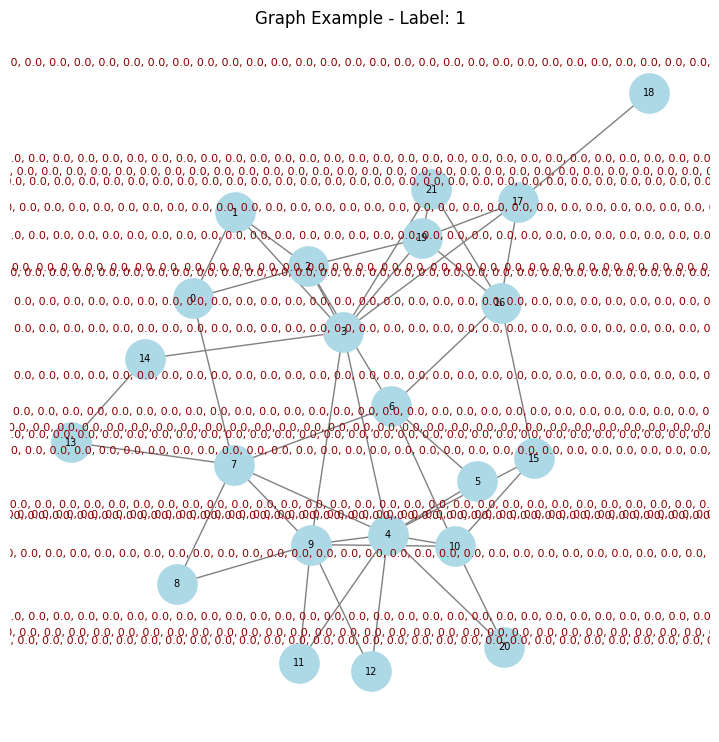

In [ ]:
# print(train_dataset.print_summary())

plot_graph(test_dataset[2])

#Create DataLoaders

In [ ]:
# Create DataLoader for batching
# This data loader is from torch_geometric.loader!! It is not from torch.utils.data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train loader: {len(train_loader)}, Validation loader: {len(val_loader)}, Test loader: {len(test_loader)}")

Train loader: 383, Validation loader: 128, Test loader: 204


In [ ]:
batch = next(iter(train_loader))
batch


DataBatch(x=[760, 259], edge_index=[2, 2490], y=[32], batch=[760], ptr=[33])

# Defining the models
First we create a simple model then when we test also the other type we modify them in order to obtain better performance


In [ ]:
#Simple GCN Model
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)  # Aggregate node features. From Node to Graph Features
        x = self.fc(x)
        return x



In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Confusion matrix + report
# -----------------------------
def plot_confusion_matrix(y_true, y_pred, class_names, dataset_name, model_name):
    """
    Creates and displays a confusion matrix to evaluate classification performance.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix — {dataset_name} — {model_name}")
    plt.show()

    print("Classification Report:\n", classification_report(y_true, y_pred, digits=4))


# -----------------------------
# Training loop
# -----------------------------
def training_loop(model,
                  train_loader,
                  val_loader,
                  train_dataset,
                  val_dataset,
                  device,
                  optimizer,
                  num_epochs,
                  criterion,
                  print_every=1,
                  model_name="GNN"):
    """
    Train the model and return histories + best state dict.

    Args:
      model: PyTorch model (expects PyG Batch objects in forward).
      train_loader, val_loader: PyG DataLoader instances that yield Batch objects.
      train_dataset, val_dataset: Dataset objects (for length).
      device: cuda/cpu
      optimizer: optimizer instance
      num_epochs: int
      criterion: loss (nn.CrossEntropyLoss or nn.BCEWithLogitsLoss typically)
      print_every: epochs between prints
    Returns:
      best_state_dict, train_losses, val_losses
    """

    model = model.to(device)
    is_ce = isinstance(criterion, nn.CrossEntropyLoss)
    is_bce = isinstance(criterion, (nn.BCEWithLogitsLoss, nn.BCEWithLogitsLoss))

    train_losses = []
    val_losses = []

    best_val = float('inf')
    best_state = None

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_train_loss = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            # Ensure node features are float for PyG conv layers
            if hasattr(batch, 'x') and batch.x is not None:
                batch.x = batch.x.type(torch.float)

            optimizer.zero_grad()
            outputs = model(batch)   # expected shape: (B, C) for CE / (B,) or (B,1) for BCE

            # Prepare targets depending on criterion
            if is_ce:
                targets = batch.y.view(-1).long().to(device)
            elif is_bce:
                # BCEWithLogitsLoss expects float targets
                targets = batch.y.view(-1).float().to(device)
                # if outputs shape is (B,1), squeeze to (B,)
                if outputs.dim() == 2 and outputs.size(1) == 1:
                    outputs = outputs.view(-1)
            else:
                # fallback: try to use targets as long (CE) first, else float
                try:
                    targets = batch.y.view(-1).long().to(device)
                except Exception:
                    targets = batch.y.view(-1).float().to(device)

            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # accumulate loss weighted by number of graphs in this batch
            n_graphs = batch.y.size(0) if hasattr(batch, 'y') else getattr(batch, 'num_graphs', 1)
            running_train_loss += loss.item() * n_graphs

        avg_train_loss = running_train_loss / len(train_dataset)
        train_losses.append(avg_train_loss)

        # validation
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                if hasattr(batch, 'x') and batch.x is not None:
                    batch.x = batch.x.type(torch.float)

                outputs = model(batch)

                if is_ce:
                    targets = batch.y.view(-1).long().to(device)
                elif is_bce:
                    targets = batch.y.view(-1).float().to(device)
                    if outputs.dim() == 2 and outputs.size(1) == 1:
                        outputs = outputs.view(-1)
                else:
                    try:
                        targets = batch.y.view(-1).long().to(device)
                    except Exception:
                        targets = batch.y.view(-1).float().to(device)

                loss = criterion(outputs, targets)
                n_graphs = batch.y.size(0) if hasattr(batch, 'y') else getattr(batch, 'num_graphs', 1)
                running_val_loss += loss.item() * n_graphs

        avg_val_loss = running_val_loss / len(val_dataset)
        val_losses.append(avg_val_loss)

        # save best
        if avg_val_loss < best_val:
            best_val = avg_val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % print_every == 0:
            print(f"Epoch {epoch:03d}  train_loss={avg_train_loss:.4f}  val_loss={avg_val_loss:.4f}")

    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed:.2f}s — best val loss {best_val:.4f}")

    # Plot losses
    plt.figure(figsize=(9,4))
    plt.plot(train_losses, label='train')
    plt.plot(val_losses, label='val')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.title(f'Loss curve ({model_name})')
    plt.legend(); plt.grid(True); plt.show()

    return best_state, train_losses, val_losses


# -----------------------------
# Testing / evaluation
# -----------------------------
def testing_model(model, dataloader, device, dataset_name="Test", model_name="GNN", threshold=0.5):
    """
    Evaluate the model on a dataloader and return accuracy (and show confusion matrix).
    Supports multi-class (logits) and binary (single-logit) outputs.
    """

    model = model.to(device)
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            if hasattr(batch, 'x') and batch.x is not None:
                batch.x = batch.x.type(torch.float)

            outputs = model(batch)   # logits

            # Multi-class: outputs shape (B, C)
            if outputs.dim() == 2 and outputs.size(1) > 1:
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
            else:
                # Binary / single-logit: apply sigmoid + threshold
                out1 = outputs.view(-1).cpu()
                probs = torch.sigmoid(out1).numpy()
                preds = (probs >= threshold).astype(int)

            labels = batch.y.view(-1).cpu().numpy()
            all_labels.append(labels)
            all_predictions.append(preds)

    all_labels = np.concatenate(all_labels)
    all_predictions = np.concatenate(all_predictions)

    accuracy = accuracy_score(all_labels, all_predictions) * 100
    class_names = [f"Class {c}" for c in np.unique(all_labels)]

    plot_confusion_matrix(all_labels, all_predictions, class_names, dataset_name, model_name)
    print(f"Accuracy on {dataset_name}: {accuracy:.2f}%")

    return accuracy


In [ ]:
from torch_geometric.data import Data, Dataset

for i, data in enumerate(train_dataset):
    # Get the expected input dimension from the vocabulary size
    expected_input_dim = len(api_to_int) # api_to_int was defined earlier and holds the vocabulary

    if data.x.shape[0] == 0:
        print(f"Sample {i}: x has 0 rows")
    # this check make sens only if we are using the OH shape
    if data.x.shape[1] != expected_input_dim:
        print(f"Sample {i}: x has wrong number of features ({data.x.shape[1]}) - Expected: {expected_input_dim}")

for i, data in enumerate(train_dataset):
  if hasattr(data, 'edge_index') and data.edge_index.numel() == 0:
      print(f"Sample {i}: edge_index is empty")

for i, data in enumerate(train_dataset):
    if not hasattr(data, 'y') or data.y.numel() == 0:
        print(f"Sample {i}: y is missing or empty")
    elif data.y.dim() > 1:
        print(f"Sample {i}: y has too many dimensions: {data.y.shape}")

## Simple GCN (with One Hot)


Using cuda
input_dim: 259
Epoch 005  train_loss=0.0978  val_loss=0.1089
Epoch 010  train_loss=0.0776  val_loss=0.1089
Epoch 015  train_loss=0.0674  val_loss=0.1062
Epoch 020  train_loss=0.0589  val_loss=0.1060
Epoch 025  train_loss=0.0528  val_loss=0.1011
Epoch 030  train_loss=0.0479  val_loss=0.1062
Epoch 035  train_loss=0.0426  val_loss=0.1016
Epoch 040  train_loss=0.0383  val_loss=0.1025
Epoch 045  train_loss=0.0353  val_loss=0.1073
Epoch 050  train_loss=0.0322  val_loss=0.1057
Epoch 055  train_loss=0.0288  val_loss=0.1112
Epoch 060  train_loss=0.0256  val_loss=0.1193
Epoch 065  train_loss=0.0247  val_loss=0.1223
Epoch 070  train_loss=0.0212  val_loss=0.1491
Epoch 075  train_loss=0.0213  val_loss=0.1372
Epoch 080  train_loss=0.0192  val_loss=0.1499
Epoch 085  train_loss=0.0189  val_loss=0.1466
Epoch 090  train_loss=0.0185  val_loss=0.1538
Epoch 095  train_loss=0.0158  val_loss=0.1602
Epoch 100  train_loss=0.0165  val_loss=0.1631
Training completed in 256.63s — best val loss 0.1010


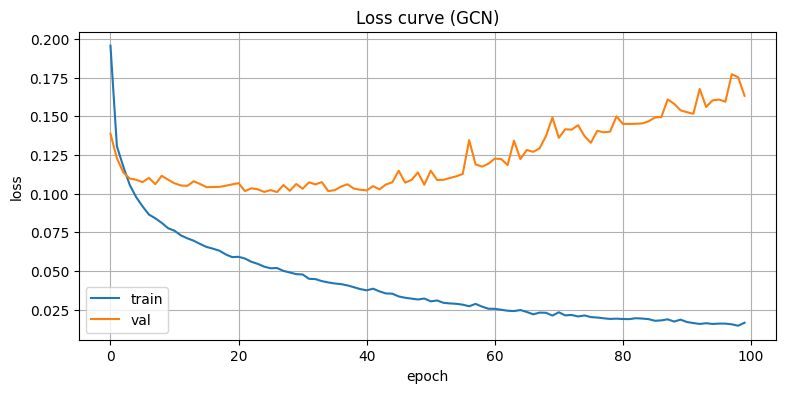

Loaded best model weights from training.


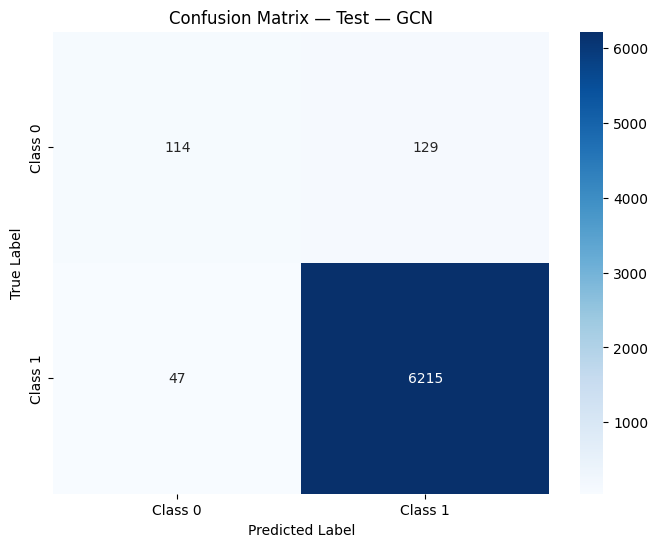

Classification Report:
               precision    recall  f1-score   support

           0     0.7081    0.4691    0.5644       243
           1     0.9797    0.9925    0.9860      6262

    accuracy                         0.9729      6505
   macro avg     0.8439    0.7308    0.7752      6505
weighted avg     0.9695    0.9729    0.9703      6505

Accuracy on Test: 97.29%
Test accuracy: 97.29%


In [ ]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()   # or use weighted CE if needed
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using {device}')

# --- ensure input_dim is correct (example using pyg_graphs list) ---
# input_dim = pyg_graphs_train[0].x.shape[1]
# or if train_feat is a DataFrame with numpy arrays:
input_dim = train_feat.iloc[0].shape[1]
print("input_dim:", input_dim)

# Instantiate model
GCNmodel = GCN(input_dim=input_dim, hidden_dim=32, output_dim=2).to(device)
optimizer = optim.Adam(GCNmodel.parameters(), lr=0.001)

# Run training and capture best state
best_state, tr_losses, va_losses = training_loop(
    GCNmodel,
    train_loader,
    val_loader,
    train_dataset,
    val_dataset,
    device,
    optimizer,
    num_epochs,
    criterion,
    print_every=5,
    model_name="GCN"
)

# Load best weights into model
if best_state is not None:
    GCNmodel.load_state_dict(best_state)
    print("Loaded best model weights from training.")

# Evaluate on test set
test_acc = testing_model(GCNmodel, test_loader, device, dataset_name="Test", model_name="GCN")
print(f"Test accuracy: {test_acc:.2f}%")


GCNmodel


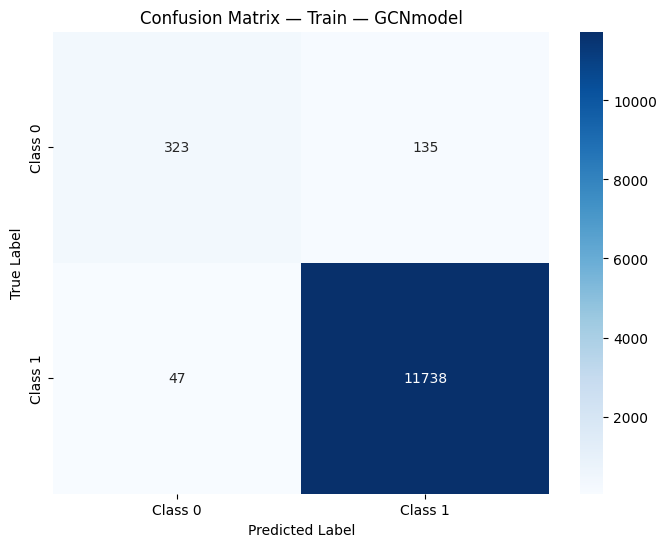

Classification Report:
               precision    recall  f1-score   support

           0     0.8730    0.7052    0.7802       458
           1     0.9886    0.9960    0.9923     11785

    accuracy                         0.9851     12243
   macro avg     0.9308    0.8506    0.8863     12243
weighted avg     0.9843    0.9851    0.9844     12243

Accuracy on Train: 98.51%
Train Accuracy: 98.5134


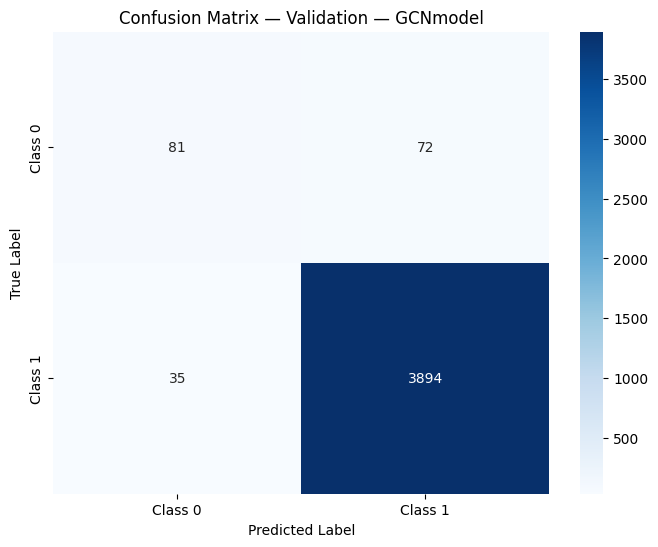

Classification Report:
               precision    recall  f1-score   support

           0     0.6983    0.5294    0.6022       153
           1     0.9818    0.9911    0.9864      3929

    accuracy                         0.9738      4082
   macro avg     0.8401    0.7603    0.7943      4082
weighted avg     0.9712    0.9738    0.9720      4082

Accuracy on Validation: 97.38%
Validation Accuracy: 97.3787


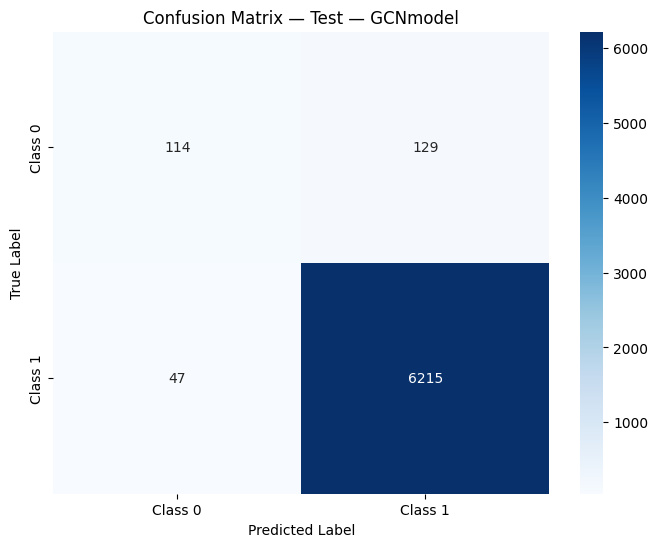

Classification Report:
               precision    recall  f1-score   support

           0     0.7081    0.4691    0.5644       243
           1     0.9797    0.9925    0.9860      6262

    accuracy                         0.9729      6505
   macro avg     0.8439    0.7308    0.7752      6505
weighted avg     0.9695    0.9729    0.9703      6505

Accuracy on Test: 97.29%
Test Accuracy: 97.2944


In [ ]:
model_names = ["GCNmodel"]
models = [GCNmodel]
for i in range(len(model_names)):
    model = models[i]
    print(model_names[i])
    train_accuracy = testing_model(model,train_loader,device,"Train",model_names[i])
    print(f'Train Accuracy: {train_accuracy:.4f}')
    val_accuracy = testing_model(model,val_loader,device,"Validation",model_names[i])
    print(f'Validation Accuracy: {val_accuracy:.4f}')
    test_accuracy = testing_model(model,test_loader,device,"Test",model_names[i])
    print(f'Test Accuracy: {test_accuracy:.4f}')

# Comparison of different architectures


In [ ]:
#GCN Model
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)  # Aggregate node features. From Node to Graph Features
        x = self.fc(x)
        return x

#GraphSAGE Model
class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)# Aggregate node features. From Node to Graph Features
        x = self.fc(x)
        return x

#GAT Model (Graph Attention Network)
class GAT(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=8):
        super(GAT, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=heads, concat=True)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=False)
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch) # Aggregate node features. From Node to Graph Features
        x = self.fc(x)
        return x


# Model with one hot encode

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_train, X_val, y_train, y_val = train_test_split(
    train_df, train_df['is_malware'],
    test_size=0.25, random_state=42, stratify=train_df['is_malware']
)

# Reset indices on all data
train_adj = X_train['adj_matrix'].reset_index(drop=True)
# Use feature_matrix_OH for GCN model without embedding
train_feat = X_train['feature_matrix_OH'].reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

val_adj = X_val['adj_matrix'].reset_index(drop=True)
# Use feature_matrix_OH for GCN model without embedding
val_feat = X_val['feature_matrix_OH'].reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

test_adj = test_df['adj_matrix'].reset_index(drop=True)
# Use feature_matrix_OH for GCN model without embedding
test_feat = test_df['feature_matrix_OH'].reset_index(drop=True)
y_test = test_df['is_malware'].reset_index(drop=True)

# Create datasets
train_dataset = GraphDataset(train_adj, train_feat, y_train)
val_dataset = GraphDataset(val_adj, val_feat, y_val)
test_dataset = GraphDataset(test_adj, test_feat, y_test)
# Create DataLoader for batching
# This data loader is from torch_geometric.loader!! It is not from torch.utils.data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train loader: {len(train_loader)}, Validation loader: {len(val_loader)}, Test loader: {len(test_loader)}")

Train loader: 383, Validation loader: 128, Test loader: 204


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume train_labels is a list or tensor of class indices (0, 1, 2)
train_labels = [label for data in train_dataset for label in [data.y.item()]]

# Compute weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Use weighted loss
criterion = nn.CrossEntropyLoss()

print(f'Using {device}')
input_dim = train_feat.iloc[0].shape[1]
dropout_rate = 0.1
weight_decay = 5e-4  # L2 regularization
num_epochs = 100



Using cuda


Epoch 005  train_loss=0.1226  val_loss=0.1204
Epoch 010  train_loss=0.1110  val_loss=0.1152
Epoch 015  train_loss=0.1059  val_loss=0.1123
Epoch 020  train_loss=0.1027  val_loss=0.1109
Epoch 025  train_loss=0.0994  val_loss=0.1195
Epoch 030  train_loss=0.0977  val_loss=0.1082
Epoch 035  train_loss=0.0959  val_loss=0.1101
Epoch 040  train_loss=0.0930  val_loss=0.1108
Epoch 045  train_loss=0.0926  val_loss=0.1101
Epoch 050  train_loss=0.0910  val_loss=0.1062
Epoch 055  train_loss=0.0885  val_loss=0.1040
Epoch 060  train_loss=0.0863  val_loss=0.1020
Epoch 065  train_loss=0.0854  val_loss=0.1037
Epoch 070  train_loss=0.0851  val_loss=0.1083
Epoch 075  train_loss=0.0824  val_loss=0.0997
Epoch 080  train_loss=0.0813  val_loss=0.1005
Epoch 085  train_loss=0.0795  val_loss=0.1004
Epoch 090  train_loss=0.0786  val_loss=0.0999
Epoch 095  train_loss=0.0778  val_loss=0.0976
Epoch 100  train_loss=0.0768  val_loss=0.0957
Training completed in 266.66s — best val loss 0.0957


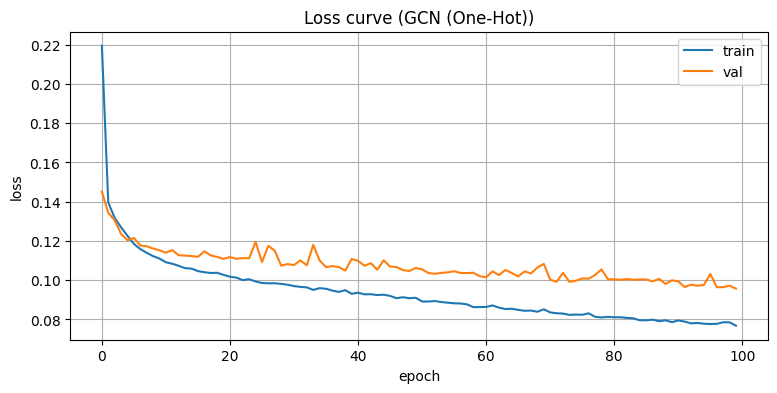

Loaded best GCN (One-Hot) weights.


In [ ]:
# GCN
GCNmodel_OH = GCN(input_dim=input_dim, hidden_dim=32, output_dim=2).to(device)
optimizer = optim.Adam(GCNmodel_OH.parameters(), lr=0.001, weight_decay=weight_decay)

# Call training_loop and CAPTURE outputs to prevent printing the large state_dict
best_state, tr_losses, va_losses = training_loop(
    GCNmodel_OH,
    train_loader,
    val_loader,
    train_dataset,
    val_dataset,
    device,
    optimizer,
    num_epochs,
    criterion,
    print_every=5,
    model_name="GCN (One-Hot)"
)

# Load the best checkpoint WITHOUT printing the dict
GCNmodel_OH.load_state_dict(best_state)
print("Loaded best GCN (One-Hot) weights.")


Epoch 005  train_loss=0.1158  val_loss=0.1160
Epoch 010  train_loss=0.1007  val_loss=0.1092
Epoch 015  train_loss=0.0907  val_loss=0.1031
Epoch 020  train_loss=0.0849  val_loss=0.1056
Epoch 025  train_loss=0.0780  val_loss=0.0979
Epoch 030  train_loss=0.0733  val_loss=0.0972
Epoch 035  train_loss=0.0689  val_loss=0.0922
Epoch 040  train_loss=0.0651  val_loss=0.0919
Epoch 045  train_loss=0.0605  val_loss=0.0816
Epoch 050  train_loss=0.0587  val_loss=0.0835
Epoch 055  train_loss=0.0559  val_loss=0.0813
Epoch 060  train_loss=0.0546  val_loss=0.0790
Epoch 065  train_loss=0.0529  val_loss=0.0964
Epoch 070  train_loss=0.0504  val_loss=0.0823
Epoch 075  train_loss=0.0498  val_loss=0.0793
Epoch 080  train_loss=0.0490  val_loss=0.0770
Epoch 085  train_loss=0.0503  val_loss=0.0767
Epoch 090  train_loss=0.0473  val_loss=0.0759
Epoch 095  train_loss=0.0481  val_loss=0.0737
Epoch 100  train_loss=0.0465  val_loss=0.0767
Training completed in 236.09s — best val loss 0.0737


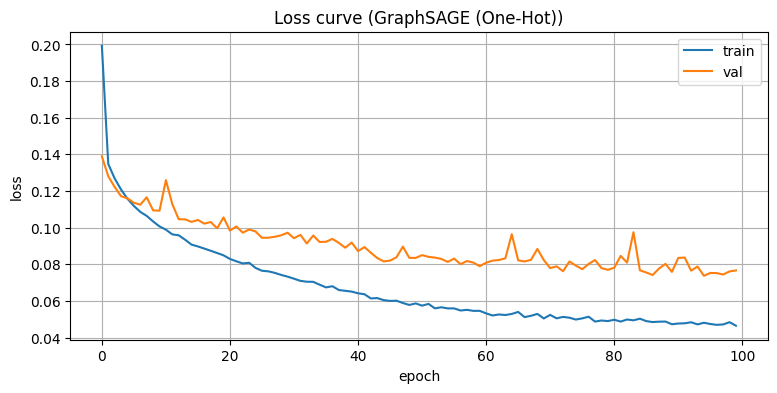

Loaded best GraphSAGE (One-Hot) weights.


In [ ]:
# -----------------------------
# GraphSAGE (One-Hot Features)
# -----------------------------
GraphSAGEmodel_OH = GraphSAGE(input_dim=input_dim, hidden_dim=32, output_dim=2).to(device)
optimizer = optim.Adam(GraphSAGEmodel_OH.parameters(), lr=0.001, weight_decay=weight_decay)

# Train and CAPTURE the best model state
best_state_sage, tr_losses_sage, va_losses_sage = training_loop(
    GraphSAGEmodel_OH,
    train_loader,
    val_loader,
    train_dataset,
    val_dataset,
    device,
    optimizer,
    num_epochs,
    criterion,
    print_every=5,
    model_name="GraphSAGE (One-Hot)"
)

# Load best weights (NO state_dict printed)
GraphSAGEmodel_OH.load_state_dict(best_state_sage)
print("Loaded best GraphSAGE (One-Hot) weights.")


Epoch 005  train_loss=0.1194  val_loss=0.1221
Epoch 010  train_loss=0.1056  val_loss=0.1146
Epoch 015  train_loss=0.1010  val_loss=0.1110
Epoch 020  train_loss=0.0985  val_loss=0.1133
Epoch 025  train_loss=0.0961  val_loss=0.1162
Epoch 030  train_loss=0.0952  val_loss=0.1095
Epoch 035  train_loss=0.0937  val_loss=0.1126
Epoch 040  train_loss=0.0924  val_loss=0.1124
Epoch 045  train_loss=0.0924  val_loss=0.1135
Epoch 050  train_loss=0.0906  val_loss=0.1173
Epoch 055  train_loss=0.0893  val_loss=0.1113
Epoch 060  train_loss=0.0900  val_loss=0.1110
Epoch 065  train_loss=0.0892  val_loss=0.1101
Epoch 070  train_loss=0.0883  val_loss=0.1103
Epoch 075  train_loss=0.0872  val_loss=0.1121
Epoch 080  train_loss=0.0868  val_loss=0.1103
Epoch 085  train_loss=0.0858  val_loss=0.1115
Epoch 090  train_loss=0.0851  val_loss=0.1155
Epoch 095  train_loss=0.0851  val_loss=0.1085
Epoch 100  train_loss=0.0848  val_loss=0.1089
Training completed in 339.84s — best val loss 0.1085


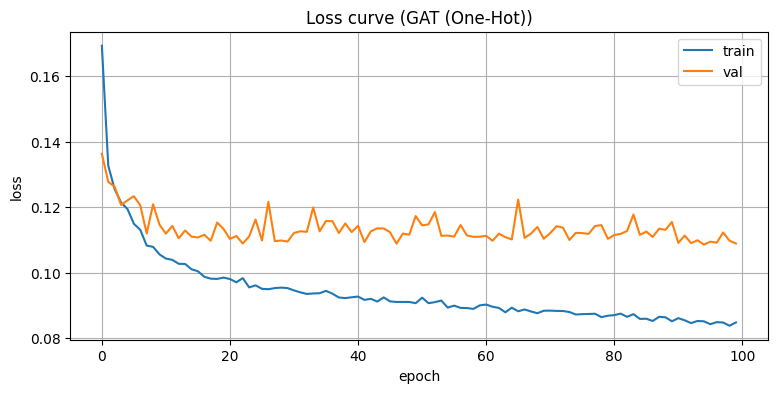

Loaded best GAT (One-Hot) weights.


In [ ]:
# -----------------------------
# GAT (One-Hot Features)
# -----------------------------
GATmodel_OH = GAT(input_dim=input_dim, hidden_dim=32, output_dim=2).to(device)
optimizer = optim.Adam(GATmodel_OH.parameters(), lr=0.001, weight_decay=weight_decay)

# Train and CAPTURE the best model state (prevents printing the full state_dict)
best_state_gat, tr_losses_gat, va_losses_gat = training_loop(
    GATmodel_OH,
    train_loader,
    val_loader,
    train_dataset,
    val_dataset,
    device,
    optimizer,
    num_epochs,
    criterion,
    print_every=5,
    model_name="GAT (One-Hot)"
)

# Load best weights silently
GATmodel_OH.load_state_dict(best_state_gat)
print("Loaded best GAT (One-Hot) weights.")


GCNmodel


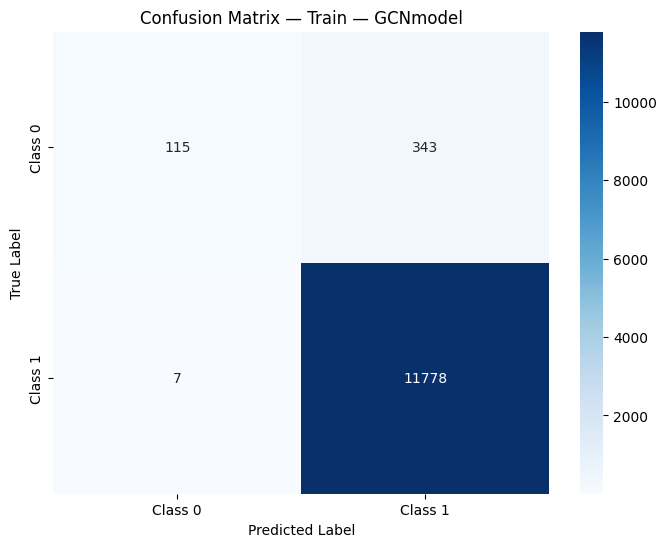

Classification Report:
               precision    recall  f1-score   support

           0     0.9426    0.2511    0.3966       458
           1     0.9717    0.9994    0.9854     11785

    accuracy                         0.9714     12243
   macro avg     0.9572    0.6252    0.6910     12243
weighted avg     0.9706    0.9714    0.9633     12243

Accuracy on Train: 97.14%
Train Accuracy: 97.1412


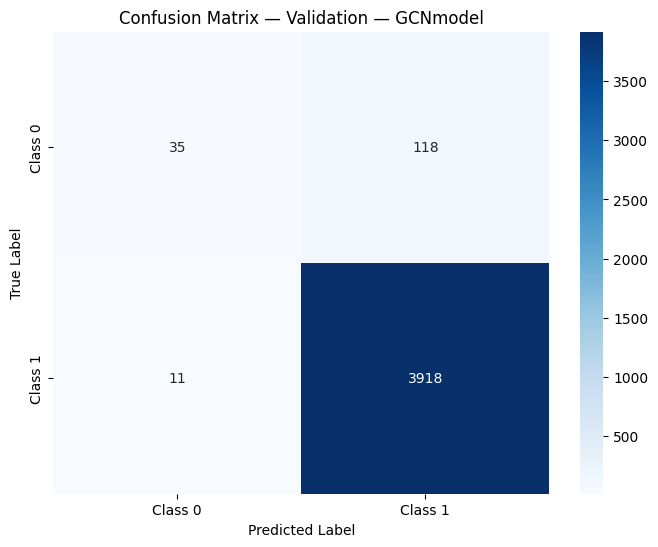

Classification Report:
               precision    recall  f1-score   support

           0     0.7609    0.2288    0.3518       153
           1     0.9708    0.9972    0.9838      3929

    accuracy                         0.9684      4082
   macro avg     0.8658    0.6130    0.6678      4082
weighted avg     0.9629    0.9684    0.9601      4082

Accuracy on Validation: 96.84%
Validation Accuracy: 96.8398


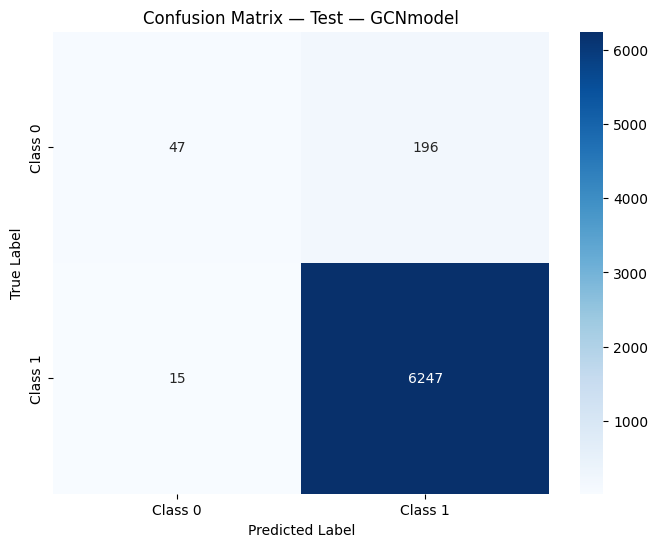

Classification Report:
               precision    recall  f1-score   support

           0     0.7581    0.1934    0.3082       243
           1     0.9696    0.9976    0.9834      6262

    accuracy                         0.9676      6505
   macro avg     0.8638    0.5955    0.6458      6505
weighted avg     0.9617    0.9676    0.9582      6505

Accuracy on Test: 96.76%
Test Accuracy: 96.7563


In [ ]:
#Test the models
model_names = ["GCNmodel"]
models = [GCNmodel_OH]
for i in range(len(model_names)):
    model = models[i]
    print(model_names[i])
    train_accuracy = testing_model(model,train_loader,device,"Train",model_names[i])
    print(f'Train Accuracy: {train_accuracy:.4f}')
    val_accuracy = testing_model(model,val_loader,device,"Validation",model_names[i])
    print(f'Validation Accuracy: {val_accuracy:.4f}')
    test_accuracy = testing_model(model,test_loader,device,"Test",model_names[i])
    print(f'Test Accuracy: {test_accuracy:.4f}')

GraphSAGEmodel


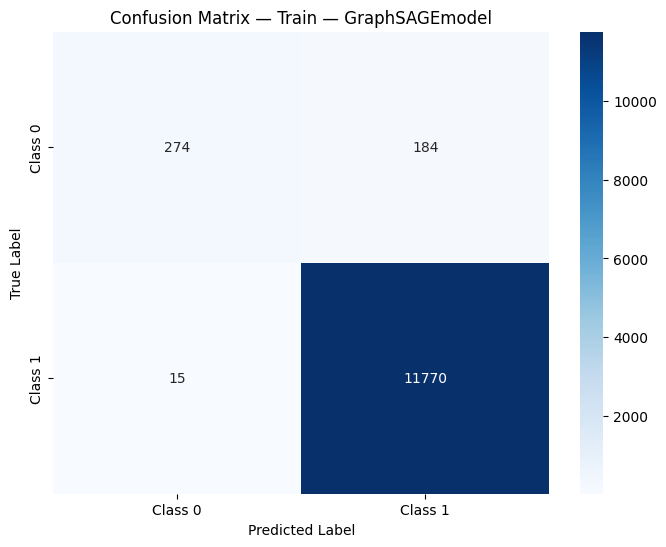

Classification Report:
               precision    recall  f1-score   support

           0     0.9481    0.5983    0.7336       458
           1     0.9846    0.9987    0.9916     11785

    accuracy                         0.9837     12243
   macro avg     0.9664    0.7985    0.8626     12243
weighted avg     0.9832    0.9837    0.9820     12243

Accuracy on Train: 98.37%
Train Accuracy: 98.3746


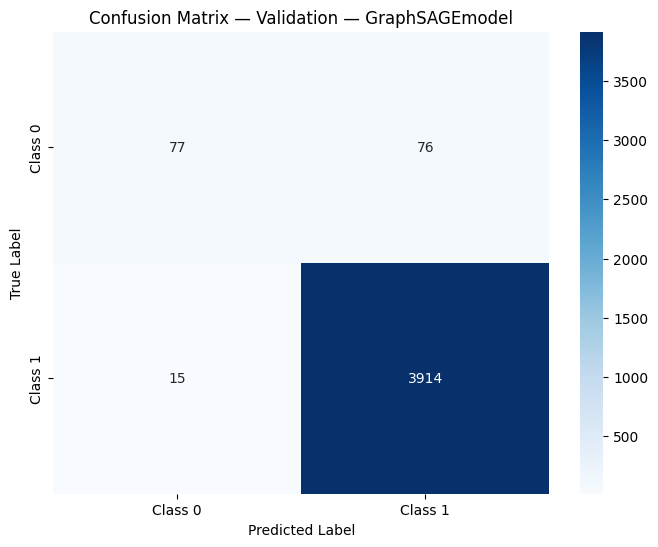

Classification Report:
               precision    recall  f1-score   support

           0     0.8370    0.5033    0.6286       153
           1     0.9810    0.9962    0.9885      3929

    accuracy                         0.9777      4082
   macro avg     0.9090    0.7497    0.8085      4082
weighted avg     0.9756    0.9777    0.9750      4082

Accuracy on Validation: 97.77%
Validation Accuracy: 97.7707


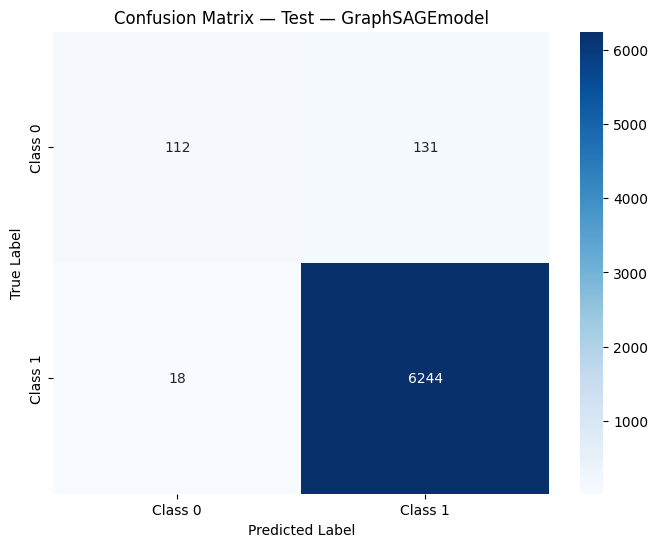

Classification Report:
               precision    recall  f1-score   support

           0     0.8615    0.4609    0.6005       243
           1     0.9795    0.9971    0.9882      6262

    accuracy                         0.9771      6505
   macro avg     0.9205    0.7290    0.7944      6505
weighted avg     0.9750    0.9771    0.9737      6505

Accuracy on Test: 97.71%
Test Accuracy: 97.7095


In [ ]:
#Test the models
model_names = ["GraphSAGEmodel"]
models = [GraphSAGEmodel_OH]
for i in range(len(model_names)):
    model = models[i]
    print(model_names[i])
    train_accuracy = testing_model(model,train_loader,device,"Train",model_names[i])
    print(f'Train Accuracy: {train_accuracy:.4f}')
    val_accuracy = testing_model(model,val_loader,device,"Validation",model_names[i])
    print(f'Validation Accuracy: {val_accuracy:.4f}')
    test_accuracy = testing_model(model,test_loader,device,"Test",model_names[i])
    print(f'Test Accuracy: {test_accuracy:.4f}')

GATmodel


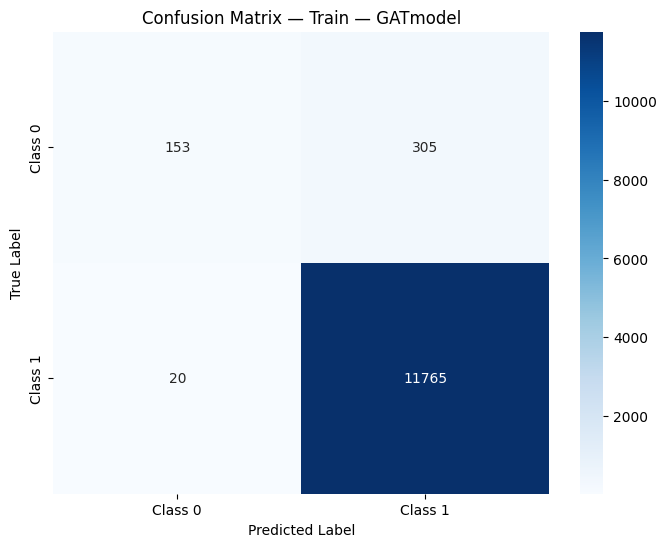

Classification Report:
               precision    recall  f1-score   support

           0     0.8844    0.3341    0.4849       458
           1     0.9747    0.9983    0.9864     11785

    accuracy                         0.9735     12243
   macro avg     0.9296    0.6662    0.7357     12243
weighted avg     0.9714    0.9735    0.9676     12243

Accuracy on Train: 97.35%
Train Accuracy: 97.3454


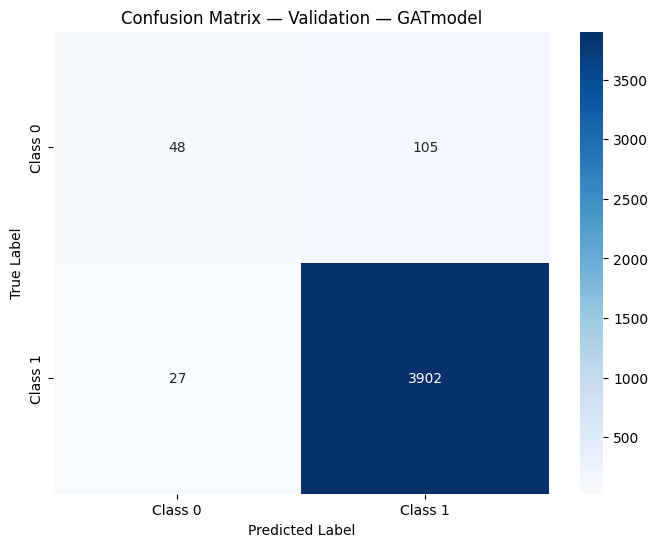

Classification Report:
               precision    recall  f1-score   support

           0     0.6400    0.3137    0.4211       153
           1     0.9738    0.9931    0.9834      3929

    accuracy                         0.9677      4082
   macro avg     0.8069    0.6534    0.7022      4082
weighted avg     0.9613    0.9677    0.9623      4082

Accuracy on Validation: 96.77%
Validation Accuracy: 96.7663


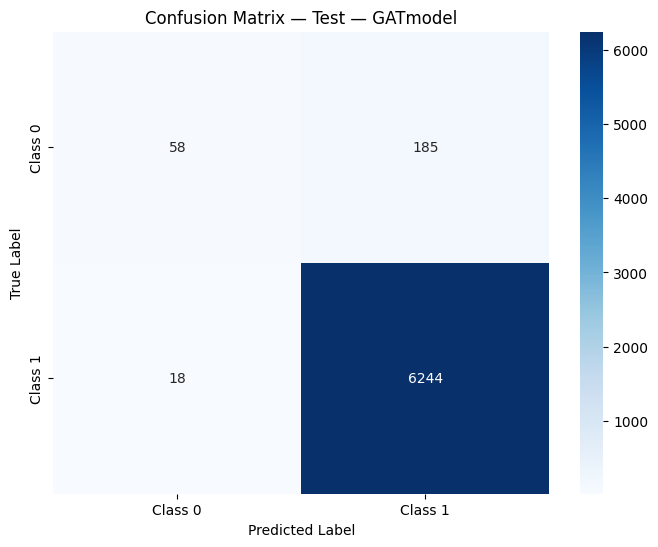

Classification Report:
               precision    recall  f1-score   support

           0     0.7632    0.2387    0.3636       243
           1     0.9712    0.9971    0.9840      6262

    accuracy                         0.9688      6505
   macro avg     0.8672    0.6179    0.6738      6505
weighted avg     0.9635    0.9688    0.9608      6505

Accuracy on Test: 96.88%
Test Accuracy: 96.8793


In [ ]:
#Test the models
model_names = ["GATmodel"]
models = [GATmodel_OH]
for i in range(len(model_names)):
    model = models[i]
    print(model_names[i])
    train_accuracy = testing_model(model,train_loader,device,"Train",model_names[i])
    print(f'Train Accuracy: {train_accuracy:.4f}')
    val_accuracy = testing_model(model,val_loader,device,"Validation",model_names[i])
    print(f'Validation Accuracy: {val_accuracy:.4f}')
    test_accuracy = testing_model(model,test_loader,device,"Test",model_names[i])
    print(f'Test Accuracy: {test_accuracy:.4f}')

In [1]:
!jupyter nbconvert --to html Final_GNN_LAB2.ipynb

[NbConvertApp] WARNING | pattern 'Final_GNN_LAB2.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
